#### functions and environment

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from PIL import Image
from numpy import concatenate, full
from scipy.stats import gaussian_kde 
from predict_loop_functions import visual_prediction, generate_noise, ensure_2d_list, get_neuron_units, predict_loop, plot_select30_hist

In [84]:
def random_images(num, train = True, path = os.path.join("//imagenet-mini")):
    """
    NOTE: directory structure for subfolers as follows
    --imagenet-mini
        -->train
            -->folder1
                -->picture1-1
                -->picture2-1.....
            -->folder2...
            -->folder3...
                -->picture1-3
                -->pictuer2-3
                -->picture....
        -->validation


    Parameters
    ----------
    num: int
        number of images 
    frames: int
        number of frames
    train: bool
        using training or validation set, defaults to train
    path: string
        defaults to cwd for training folder, otherwise path to train/val. folders needed

    Returns
    -------
    folder_id
        folder # used
    image_ids
        image #'s used
    np.stack(final_array)
        stack of num DIFFERENT images in one object, shape (num, 144, 256)
    """

    if train == True: train_val = '//train' 
    else: train_val = '//val'

    folder_path = path + train_val # get path to train/val folders
    initial_folders = os.listdir(folder_path)

    folder_id = np.random.randint(0, len(initial_folders) - 1) # get path to random folder within train/val
    image_folder_path = folder_path + '//' + initial_folders[folder_id]

    image_folder = os.listdir(image_folder_path) # path to folder in train/val with images

    image_ids = np.random.randint(0,len(image_folder) - 1, size = num)
    final_array = np.empty(shape = (num, 144, 256))

    for i in range(num):
        image_name = '//' + image_folder[i]
        image_path = image_folder_path + image_name
        image = Image.open(image_path)
        image = image.convert('L')
        if image.size != (256, 144): image = image.resize((256, 144))
        image = np.array(image)
        final_array[i] = image

    return folder_id, image_ids, np.stack(final_array, axis = 0)

# turning curve func. is for a single predicted array
def turning_curve(array, title, ten_neurons):
    fix, ax = plt.subplots(1,1, figsize = (8,6))
    
    mean_array = np.mean(array, axis = 1)
    image_ids = np.array([i for i in range(5)], dtype = int)
    
    # error bar
    variance = np.var(array, axis = 1)
    std_dev = np.sqrt(variance)
    
    for neuron in ten_neurons:
        neuron_predictions = mean_array[:, neuron]
        plt.errorbar(image_ids, neuron_predictions, yerr=std_dev[:, neuron], marker = 'o', linestyle = '-', capsize=5)
    
    plt.title(f"Turning Curve for Imagenet Images\n{title}")
    plt.xlabel("Image ID")
    plt.ylabel('Mean Predicted Spike Count')

    ax.xaxis.set_major_locator(MultipleLocator(1))
    plt.grid()
    plt.tight_layout()
    plt.show()



In [3]:
folder_id, image_ids, image_stack = random_images(5, path = "C://Users//joshf//Downloads//imagenet-mini")

In [69]:
# save this image stack to computer
np.save('image_stack_july16.npy', image_stack)

# to load
"""
loaded = np.load('image_stack_july16.npy')
"""

"\nloaded = np.load('image_stack_july16.npy')\n"

In [4]:
gray_frames = np.full(shape = (144, 256), fill_value = 128)
# make image id = 0 gray_frames
image_stack[0] = gray_frames
image_stack.shape

(5, 144, 256)

In [10]:
print(f'folder id: {folder_id}; image ids :{image_ids}')

folder id: 909; image ids :[ 1  0 11 13  5]


*for future reference, use these images*

folder id: 909; image ids: [ 1  0 11 13  5] 

Note image with id = 1 will be replaced with gray frames per above

In [7]:
neurons = np.array([1685,368,1571,670,1918,1231,6795,6492,2507,1444,2361,6699,6672,6790,6209,6699,
           1447,5583,2237,2161,7217,5114,4321,4823,6822,5935,823,6501,6819,5782])

#### predictions

In [70]:
# load image stack originally used
image_stack = np.load('image_stack_july16.npy')

In [12]:
dynamic3, dynamic3_mean, dynamic3_var = predict_loop("dynamic", 30, image_stack, 3, [[4,7]], num_frames = 10)

In [13]:
dynamic15, dynamic15_mean, dynamic15_var = predict_loop("dynamic", 30, image_stack, 15, [[4,7]], num_frames = 10)

In [14]:
dynamic30, dynamic30_mean, dynamic30_var = predict_loop("dynamic", 30, image_stack, 30, [[4,7]], num_frames = 10)

In [15]:
constant3, constant3_mean, constant3_var = predict_loop('constant', 30, image_stack, 3, [[4,7]], num_frames = 10)

In [16]:
constant15, constant15_mean, constant15_var = predict_loop('constant', 30, image_stack, 15, [[4,7]], num_frames = 10)

In [17]:
constant30, constant30_mean, constant30_var = predict_loop('constant', 30, image_stack, 30, [[4,7]], num_frames = 10)

In [18]:
stochastic, stochastic_mean, stochastic_var = predict_loop('stochastic binarization', 
                                                           30, image_stack, 0, # sigma trivial here
                                                           [[4,7]], num_frames = 10)

#### turning curves

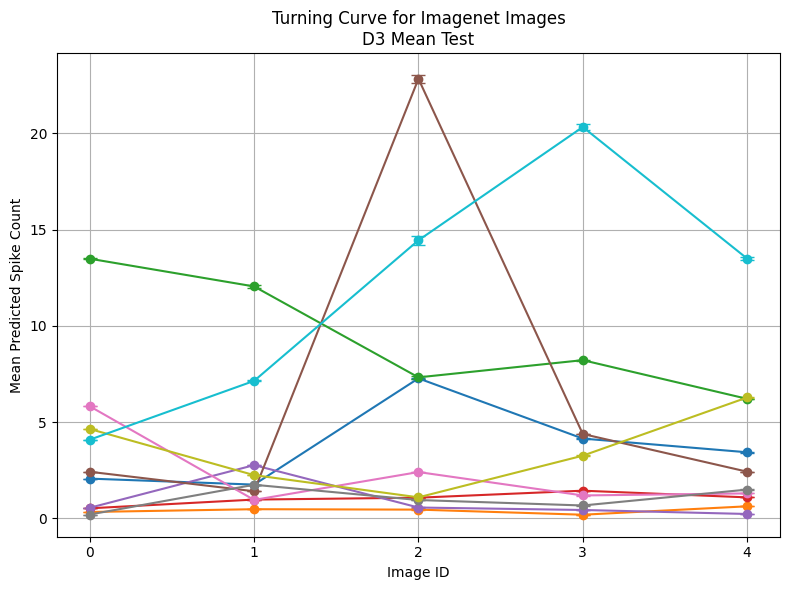

In [85]:
turning_curve(dynamic3, "D3 Mean Test", neurons[:10])

#### KDE curve

In [62]:
bw = 0.5 # how to determine bandwidth

padding = 2 * bw

num_points = 30 # for 30 neurons?

In [63]:
dynamic3_var.shape

(5, 7493)

In [ ]:
# dynamic 3
start = np.min(dynamic3_var) - padding
stop = np.max(dynamic3_var) + padding

d3x = np.linspace(start, stop, num_points)

# which dataset to use for KDE, var or regular? what about when plotting values (see below)? 
kde_d3 = gaussian_kde(dynamic3_var.flatten(), bw_method = bw) # input here needs to be 1D, AI said to choose one column however is flattening correct here?
kde_d3_values = kde_d3(d3x)

In [ ]:
def kde_curve(array, linspace, kde_values, title: str, color = 'darkblue'):
    # input array needs to be REGULAR version (for now) of var. data
    plt.plot(linspace, kde_values, color = color, label = 'KDE Curve')
    plt.fill_between(linspace, kde_values, alpha = 0.2, color = color)
    plt.scatter(array.flatten(), np.zeros_like(array.flatten()), color = 'red', label = 'Data Points') # should this be activation rate predictions? how to flatten/transform that array?
    plt.title(f'Kernel Density Estimation: {title}')
    plt.xlabel('Variance')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()


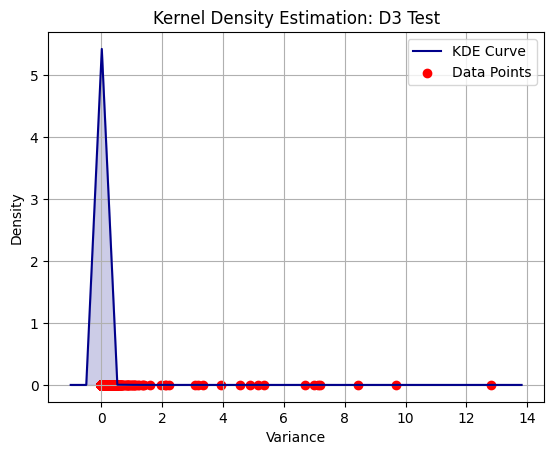

In [66]:
kde_curve(dynamic3_var, d3x, kde_d3_values, "D3 Test")